# 05 - Visualizaciones exploratorias

**Responsable principal:** María José Girón

**Actividad de la guia:** 4d (graficos exploratorios) y parte de *Analisis Exploratorio* (30 pts: histogramas, cajas y bigotes, dispersion, graficos de barra).

**Objetivo de este notebook:** generar y guardar en `reports/figures/` los graficos que se van a usar en el informe y la presentacion. Independiente de 01/02/03/04.

In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import data_loading as dl

sns.set_theme(style="whitegrid")


In [8]:
FIGURES_DIR = config.ROOT_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [9]:
# Cargar la metadata de las secuencias
train_df = dl.load_train_index()

print("Dimensiones de train_df:", train_df.shape)
display(train_df.head())

Dimensiones de train_df: (67208, 5)


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


## 1. Histograma: longitud de secuencia

*Interpretación*

- Sesgo a la derecha, la moda se concentra entre los 100 y 150 frames por seña.
- La mayor parte de los datos se ubica ene lr ango de 50 a 250 frames.
- Existe una cola hacia la derecha (400-750 framse), indicando que hay señas o participantes con pausas largas o frases muy extensas.

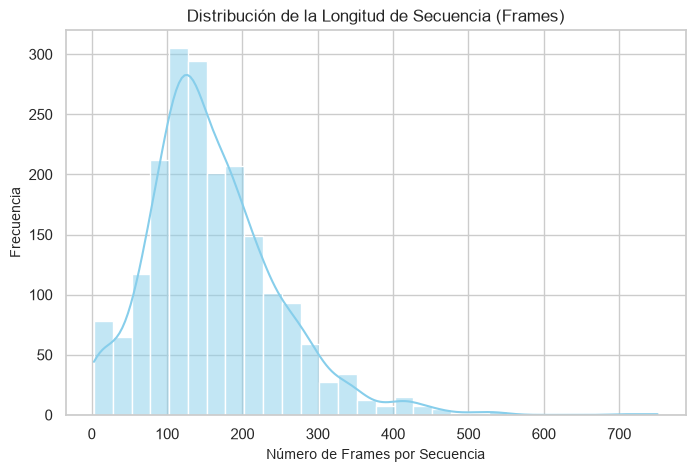

In [11]:
# Cargar la muestra representativa de secuencias para obtener 'seq_len'
sample_rows = []
for rel_path in config.SAMPLE_LANDMARK_PATHS:
    df_sample = dl.load_landmarks(dl.landmark_path(rel_path))
    
    # Si 'frame' está como columna o índice, contamos los frames únicos por secuencia
    if "frame" in df_sample.columns:
        counts = df_sample.groupby("sequence_id")["frame"].nunique()
    else:
        # Si la secuencia está agrupada por el índice
        counts = df_sample.groupby(level=0).size()

    for seq_id, frame_count in counts.items():
        sample_rows.append({"sequence_id": seq_id, "seq_len": frame_count})

sample_seq_df = pd.DataFrame(sample_rows)

# Crear la figura y el histograma
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=sample_seq_df, x="seq_len", bins=30, kde=True, ax=ax, color="skyblue")

ax.set_title("Distribución de la Longitud de Secuencia (Frames)", fontsize=12)
ax.set_xlabel("Número de Frames por Secuencia", fontsize=10)
ax.set_ylabel("Frecuencia", fontsize=10)

# Guardar la figura
fig.savefig(FIGURES_DIR / "hist_seq_len.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Histograma: longitud de frase

- Existe un pico inusual, denotando una moda en 12 carácteres.
- Fuera del punto anterior, las frases varían entre 10 y 30 caracteres, decayendo a medida que aumenta la longitud.
- Frases con <8 caracteres son inusuales.
- Mayor parte de frases objetivas tendrán longitud máxima de alrededor de 31 caracteres.

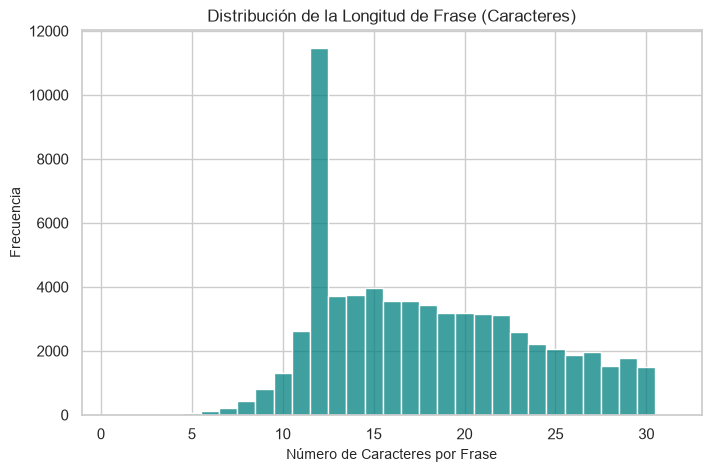

In [12]:
# Calcular la longitud del texto/frase en train_df
train_df["phrase_len"] = train_df["phrase"].str.len()

# Crear la figura y el histograma
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=train_df, x="phrase_len", discrete=True, ax=ax, color="teal")

ax.set_title("Distribución de la Longitud de Frase (Caracteres)", fontsize=12)
ax.set_xlabel("Número de Caracteres por Frase", fontsize=10)
ax.set_ylabel("Frecuencia", fontsize=10)

# Guardar la figura
fig.savefig(FIGURES_DIR / "hist_phrase_len.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Diagrama de caja y bigotes: longitud de secuencia por participante

- Al haber varios participantes (y la gráfica se veía saturada), tomamos la decisión de tomar los top 15 con más datos.
- La mediana de cada caja varía según el participante, mostranso diferencias notables de velocidad.
- La línea roja actúa como umbral de normalidad global, participantes como el 219 y 76 están alineados con la mediana, representando la velocidad promedio de gesticulación.
- Participantes como el 88, 59 y 154 tienen duraciones variables (puede que mezclen señas rápidas y lentas)
- Existen puntos atípicos en la parte superior, reflejando pausas largas antes/después de la seña o posibles fallos de formato de grabación.

C:\Users\maria\AppData\Local\Temp\ipykernel_9008\324562471.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


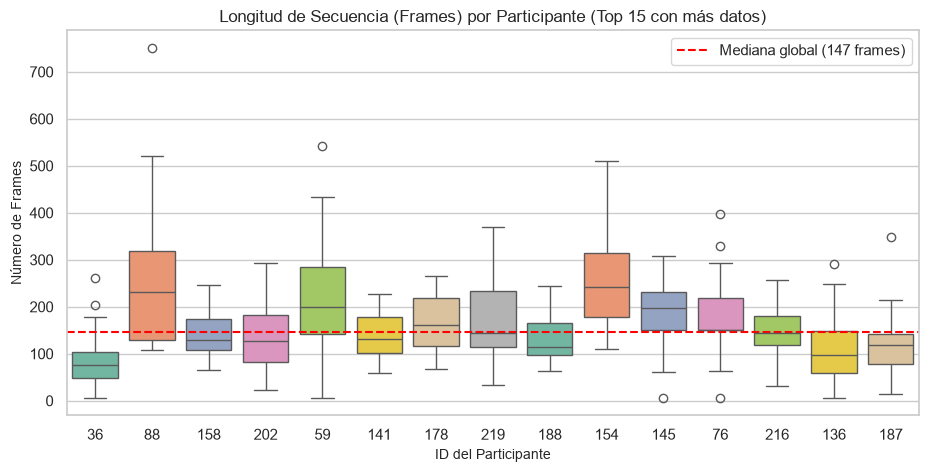

Mediana global de frames: 147.0
Medianas por participante:
participant_id
36      75.5
88     231.0
158    129.5
202    128.0
59     200.0
141    132.0
178    161.0
219    144.0
188    115.0
154    241.0
145    197.0
76     151.0
216    143.5
136     97.5
187    118.0
Name: seq_len, dtype: float64


In [15]:
# Unir la longitud de secuencia con los participantes según la muestra
seq_part_df = sample_seq_df.merge(
    train_df[["sequence_id", "participant_id"]], 
    on="sequence_id", 
    how="inner"
)

# Seleccionar el Top 15 de participantes con mayor número de secuencias en la muestra
top_participants = seq_part_df["participant_id"].value_counts().head(15).index
filtered_df = seq_part_df[seq_part_df["participant_id"].isin(top_participants)].copy()

# Ordenar las categorías por la frecuencia para una presentación limpia
filtered_df["participant_id"] = pd.Categorical(
    filtered_df["participant_id"], 
    categories=top_participants, 
    ordered=True
)

# Crear la figura y el boxplot
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=filtered_df, 
    x="participant_id", 
    y="seq_len", 
    palette="Set2", 
    ax=ax
)

# Añadir línea de mediana global para comparación visual
global_median = seq_part_df["seq_len"].median()
ax.axhline(global_median, color="red", linestyle="--", linewidth=1.5, label=f"Mediana global ({global_median:.0f} frames)")

ax.set_title("Longitud de Secuencia (Frames) por Participante (Top 15 con más datos)", fontsize=12)
ax.set_xlabel("ID del Participante", fontsize=10)
ax.set_ylabel("Número de Frames", fontsize=10)
ax.legend(loc="upper right")

# Guardar la figura
fig.savefig(FIGURES_DIR / "box_seq_len_by_participant.png", dpi=150, bbox_inches="tight")
plt.show()

# Imprimir resumen de métricas para la redacción del informe
print(f"Mediana global de frames: {global_median:.1f}")
print("Medianas por participante:")
print(filtered_df.groupby("participant_id")["seq_len"].median())

## 4. Grafico de dispersion: longitud de secuencia vs. longitud de frase

- Como r=0.602, podemos decir que tiene una tendencia: a mayor número de caracteres en la frase, mayor es la cantidad de fotogramas requeridos para transmitirla.
- Para una misma longitud de frase, existe una variabilidad considerable entre frames, pues existen variabilidades en la velocidad de deletreo.
- Hay puntos cercanos a 0 frames en varias longitudes de frase y puntos aislados, indicando posibles datos corruputos o recortados.
- Longitud del input guarda una relación proporcional pero la variable con la longitud del output (texto).

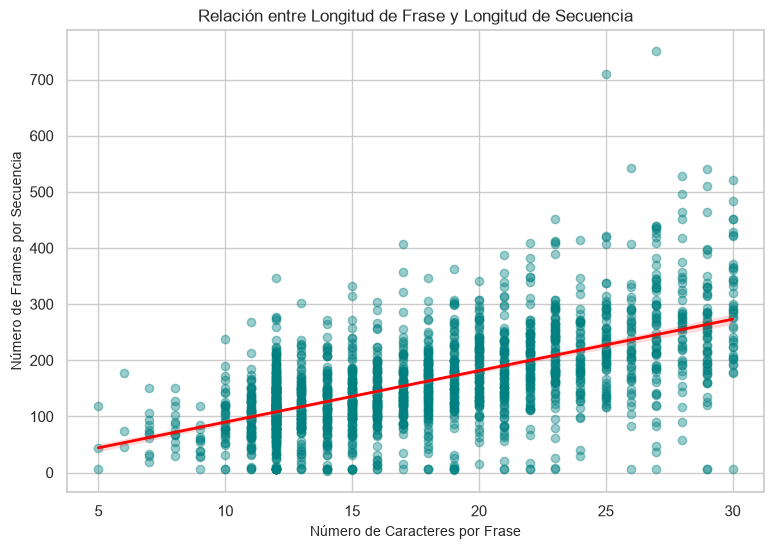

Coeficiente de correlación de Pearson: 0.602


In [16]:
# Unir longitud de secuencia con longitud de frase en la muestra
scatter_df = sample_seq_df.merge(
    train_df[["sequence_id", "phrase_len"]], 
    on="sequence_id", 
    how="inner"
)

# Crear la figura y el grafico de dispersion
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=scatter_df, 
    x="phrase_len", 
    y="seq_len", 
    scatter_kws={"alpha": 0.4, "color": "teal"}, 
    line_kws={"color": "red", "linewidth": 2}, 
    ax=ax
)

ax.set_title("Relación entre Longitud de Frase y Longitud de Secuencia", fontsize=12)
ax.set_xlabel("Número de Caracteres por Frase", fontsize=10)
ax.set_ylabel("Número de Frames por Secuencia", fontsize=10)

# Guardar la figura
fig.savefig(FIGURES_DIR / "scatter_seq_vs_phrase.png", dpi=150, bbox_inches="tight")
plt.show()

# Calcular y mostrar la correlación de Pearson
corr = scatter_df["phrase_len"].corr(scatter_df["seq_len"])
print(f"Coeficiente de correlación de Pearson: {corr:.3f}")

## 5. Grafico de barras: frecuencia de caracteres en las frases

- Respecto a caracteres más frecuentes, se puden visualizar las vocales e y e, seguidas de otras estandar como o, r, t...
- Hay una presencia de dígitos del 0 - 9 y de otros caracteres especiales. El dataset sí contiene formatos estandarizados de números telefónicos o códigos.
- Existe una disparidad entre las clases más comunes y símbolos.

C:\Users\maria\AppData\Local\Temp\ipykernel_9008\801009773.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


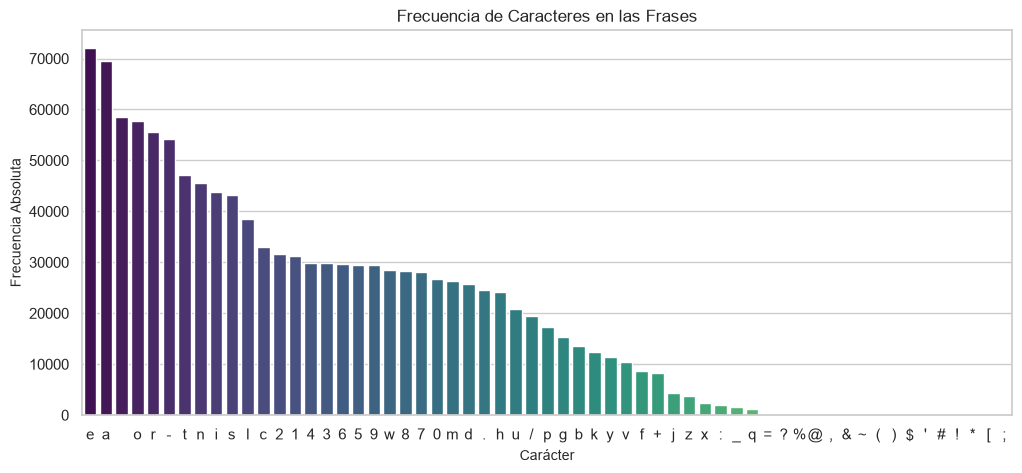

In [17]:
from collections import Counter

# Contar la frecuencia de cada carácter individual en el total de frases
char_counts = Counter("".join(train_df["phrase"].dropna()))
char_df = pd.DataFrame(char_counts.items(), columns=["character", "frequency"])
char_df = char_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)

# Crear la figura y el gráfico de barras
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=char_df, 
    x="character", 
    y="frequency", 
    palette="viridis", 
    ax=ax
)

ax.set_title("Frecuencia de Caracteres en las Frases", fontsize=12)
ax.set_xlabel("Carácter", fontsize=10)
ax.set_ylabel("Frecuencia Absoluta", fontsize=10)

# Guardar la figura
fig.savefig(FIGURES_DIR / "bar_char_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visualizacion de una secuencia (trayectoria de landmarks de mano)

- Cada punto clave está representado en su propia columna y cada fila representa un frame individual de la secuencia.
- Las coordenadas x e y están acotadas dentro del rango [0, 1], indicando una normalización previa al espacio de la cámara.
- El desplazamiento de los cúmulos de puntos muestra la extensión y la trayectoria del movimiento de la mano durante la seña.
- A pesar de ser una proyección de múltiples fotogramas superpuestos, se distinguen zonas de alta densidad de puntos que corresponden a las posiciones recurrentes de la muñeca y las puntas de los dedos durante la gesticulación.
- Las zonas con menor densidad de puntos (los extremos de la nube) representan movimientos rápidos o de transición donde la mano pasa pocos frames en esa posición.

Columnas disponibles: ['frame', 'x_face_0', 'x_face_1', 'x_face_2', 'x_face_3', 'x_face_4', 'x_face_5', 'x_face_6', 'x_face_7', 'x_face_8']


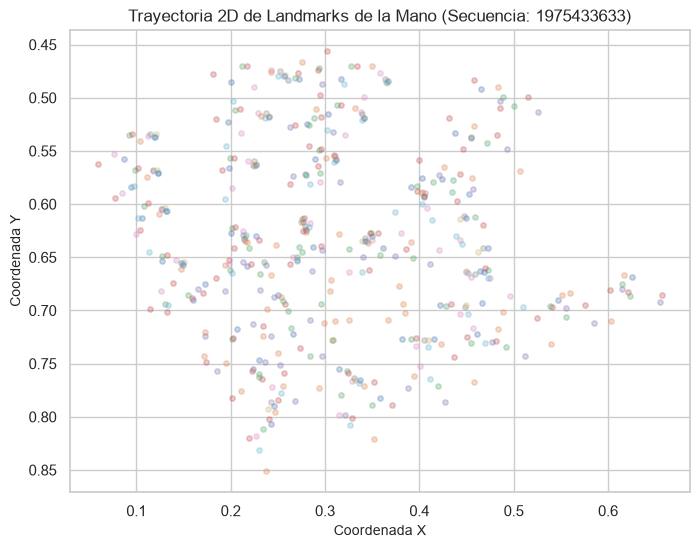

In [19]:
# 1. Cargar el primer archivo de la muestra
sample_rel_path = config.SAMPLE_LANDMARK_PATHS[0]
sample_df = dl.load_landmarks(dl.landmark_path(sample_rel_path))

# Imprimir las columnas para verificar la estructura exacta si fuera necesario
print("Columnas disponibles:", sample_df.columns.tolist()[:10])

# 2. Filtrar una secuencia específica
first_seq_id = sample_df.index.unique()[0] if sample_df.index.name == "sequence_id" else sample_df["sequence_id"].iloc[0]

if "sequence_id" in sample_df.columns:
    seq_data = sample_df[sample_df["sequence_id"] == first_seq_id].copy()
else:
    seq_data = sample_df.loc[[first_seq_id]].copy()

# 3. Detectar dinámicamente cómo están estructuradas las columnas/tipos
if "type" in seq_data.columns:
    hand_df = seq_data[seq_data["type"].isin(["right_hand", "left_hand"])].dropna(subset=["x", "y"])
elif "landmark_type" in seq_data.columns:
    hand_df = seq_data[seq_data["landmark_type"].isin(["right_hand", "left_hand"])].dropna(subset=["x", "y"])
else:
    # Si las columnas vienen en formato ancho (p. ej. x_right_hand_0, y_right_hand_0)
    # Filtramos columnas de la mano derecha o izquierda
    hand_cols = [c for c in seq_data.columns if "right_hand" in c or "left_hand" in c]
    hand_df = seq_data[hand_cols].copy()

# 4. Graficar trayectoria según el formato de datos obtenido
fig, ax = plt.subplots(figsize=(8, 6))

if "x" in hand_df.columns and "y" in hand_df.columns:
    frame_vals = hand_df["frame"] if "frame" in hand_df.columns else hand_df.index
    scatter = ax.scatter(
        hand_df["x"], 
        hand_df["y"], 
        c=frame_vals, 
        cmap="plasma", 
        alpha=0.6, 
        s=25
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Frame (Tiempo)", fontsize=10)
else:
    # Extraer todas las coordenadas X e Y de la mano por frame en formato ancho
    x_cols = [c for c in hand_cols if c.startswith("x_")]
    y_cols = [c for c in hand_cols if c.startswith("y_")]
    
    for idx, row in seq_data.iterrows():
        ax.scatter(row[x_cols], row[y_cols], alpha=0.3, s=15, label=f"Frame {idx}" if idx == 0 else "")

ax.set_title(f"Trayectoria 2D de Landmarks de la Mano (Secuencia: {first_seq_id})", fontsize=12)
ax.set_xlabel("Coordenada X", fontsize=10)
ax.set_ylabel("Coordenada Y", fontsize=10)
ax.invert_yaxis()

# Guardar la figura
fig.savefig(FIGURES_DIR / "sample_hand_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Notas de los graficos

- Existe una correlación moderada-fuerte ($r = 0.602$) entre el número de caracteres y la cantidad de frames. Sin embargo, la variabilidad en los tiempos por participante (con medianas de aproximadamente ~75 y 240 frames) necesitaremos manejar longitudes de entrada dinámicas en el modelo.

- Se puede visualizar un sesgo pronunciado hacia vocales y dígitos estándar, mientras que caracteres como j, z o símbolos tienen muy pocas muestras, lo que exigirá atender la métrica por clase durante el entrenamiento.

- La trayectoria 2D de las señalizaciones corporales indica que la información de posición conserva la topología espacial de las señas, ofreciendo un mapa compacto del movimiento continuo a través del tiempo.